Ejemplo para verificar reconstrucción de espectro direccional

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import envelope_celeris as e

Tabla de Celeris de ejemplo: [A, T, theta_deg, phi]

T cortos + h grande => |κ| grande => la envolvente cabe sin problemas


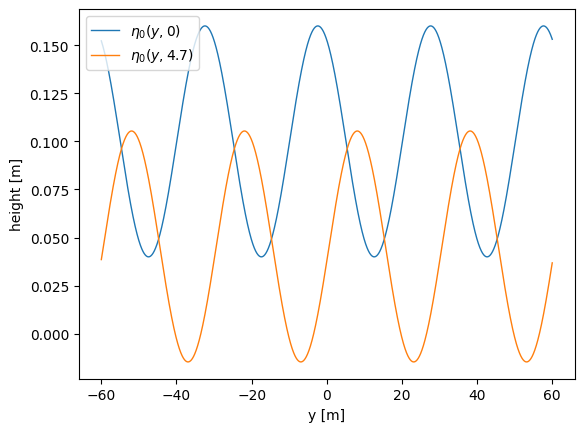

In [2]:

table0 = np.array([
    [0.10,  4.0,   0.0, 0.0],
    [0.06,  2.0,  10.0, 0.5],
    # [0.04,  5.0,  -5.0, 1.2],
])
h = 1.0  # profundidad

y = np.linspace(-60, 60, 4001)
eta_0 = e.eta_from_table(table0, h, y, t=0.0)
eta_0_t = e.eta_from_table(table0, h, y, t=4.7)

plt.plot(y, eta_0, lw=1.0, label=r"$\eta_0(y,0)$")
plt.plot(y, eta_0_t, lw=1.0, label=r"$\eta_0(y,4.7)$")
plt.xlabel("y [m]")
plt.ylabel("height [m]")
plt.legend()

Envolvente: rectangular suavizada con erf, soporte [-30, 30] m

σ controla la suavidad; valores más grandes => menos leakage espectral,

mejor reconstrucción dentro de los modos propagantes.


In [3]:
env = e.erf_rectangle(a=-30.0, b=30.0, sigma=8.0)

# y_max = 60 m: la nueva tabla debe reconstruir bien hasta ahí
table1 = e.apply_envelope_to_table(
    table0, h, env, y_max=60.0,
    pad=10.0, samples_per_lobe=16, amplitude_threshold=1e-4,
)

print(f"Tabla original:  {table0.shape[0]} modos")
print(f"Tabla con env.:  {table1.shape[0]} modos  ({env.name})")


Tabla original:  2 modos
Tabla con env.:  492 modos  (erf(σ=8))


Verificación: comparar eta_0(y,0)*B(y) con eta_1(y,0) reconstruida

In [4]:
target = eta_0 * env.B(y)
eta_1 = e.eta_from_table(table1, h, y, t=0.0)

err = np.sqrt(np.mean((eta_1 - target) ** 2))
rel = err / np.sqrt(np.mean(target ** 2))
print(f"RMS reconstrucción en y∈[-60,60]: {err:.3e} m  (rel: {rel:.2%})")


RMS reconstrucción en y∈[-60,60]: 5.675e-06 m  (rel: 0.01%)


También en otro instante para chequear la dependencia temporal

In [5]:

eta_0_t = e.eta_from_table(table0, h, y, t=3.7)
target_t = eta_0_t * env.B(y)
eta_1_t = e.eta_from_table(table1, h, y, t=3.7)
err_t = np.sqrt(np.mean((eta_1_t - target_t) ** 2))
rel_t = err_t / np.sqrt(np.mean(target_t ** 2))
print(f"RMS reconstrucción en t=3.7 s:    {err_t:.3e} m  (rel: {rel_t:.2%})")

RMS reconstrucción en t=3.7 s:    5.172e-06 m  (rel: 0.01%)


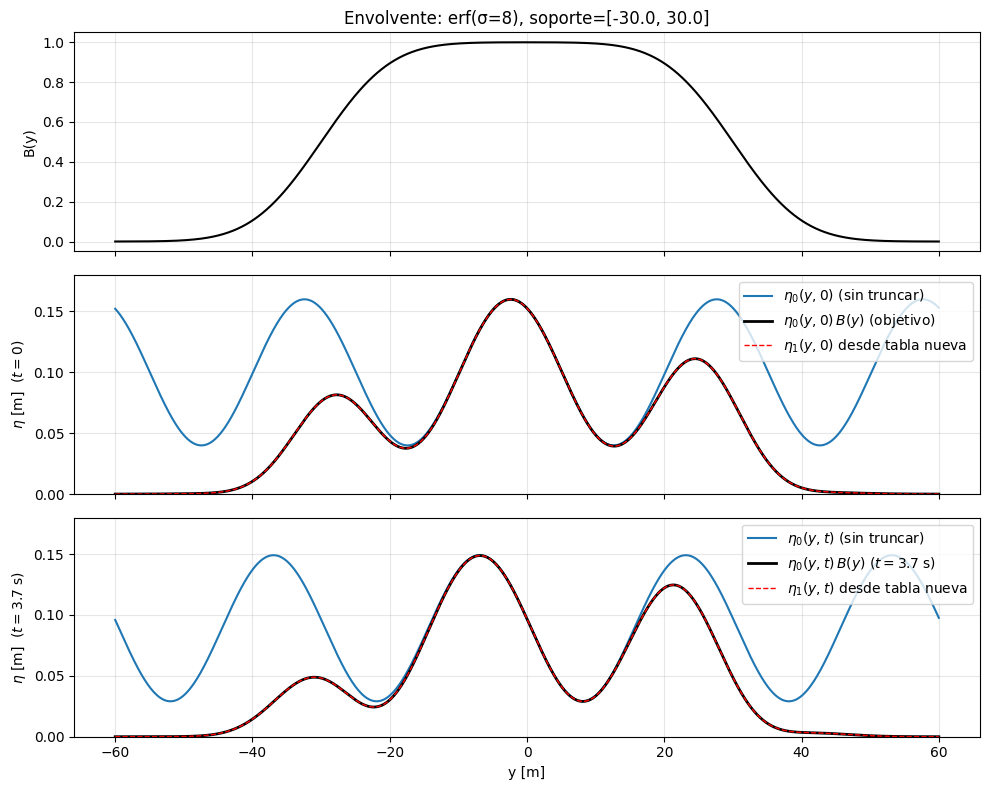

In [14]:
# Plot de verificación
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(y, env.B(y), 'k-')
axes[0].set_ylabel("B(y)")
axes[0].set_title(f"Envolvente: {env.name}, soporte=[{env.a}, {env.b}]")
axes[0].grid(alpha=0.3)


axes[1].plot(y, eta_0, label=r"$\eta_0(y,0)$ (sin truncar)") 
axes[1].plot(y, target, 'k-',  lw=2.0, label=r"$\eta_0(y,0)\,B(y)$ (objetivo)")
axes[1].plot(y, eta_1,  'r--', lw=1.0, label=r"$\eta_1(y,0)$ desde tabla nueva")
axes[1].set_ylabel(r"$\eta$ [m]  ($t=0$)")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0,0.18)

axes[2].plot(y, eta_0_t, label=r"$\eta_0(y,t)$ (sin truncar)") 
axes[2].plot(y, target_t, 'k-',  lw=2.0, label=r"$\eta_0(y,t)\,B(y)$ ($t=3.7$ s)")
axes[2].plot(y, eta_1_t,  'r--', lw=1.0, label=r"$\eta_1(y,t)$ desde tabla nueva")
axes[2].set_xlabel("y [m]")
axes[2].set_ylabel(r"$\eta$ [m]  ($t=3.7$ s)")
axes[2].legend(loc="upper right")
axes[2].grid(alpha=0.3)
axes[2].set_ylim(0,0.18)

plt.tight_layout()
# plt.savefig("envelope_check.png", dpi=120)
